# HumanEval pass@k from saved per-run task results

This notebook loads previously saved **per-run task result CSV files** from Google Drive, reconstructs the number of correct samples per HumanEval task for each model, computes **pass@k** for **k = 1, ..., 10**, and reports model comparisons.

Statistical testing is split into two levels:

1. **Run-level benchmark tests** based on the 10 benchmark runs per model. These use **Welch's t-test** as the main pairwise test because it does not assume equal variances, with **Mann–Whitney U** as a nonparametric robustness check. Effect sizes are also reported.
2. **Task-level paired pass@k tests** across HumanEval tasks. These are retained as descriptive/secondary analyses because the same tasks are evaluated for each model.

With only 10 runs per model, interpret p-values cautiously and emphasize effect sizes, confidence intervals, and consistency across runs.


In [1]:
# =========================
# 1. Setup
# =========================
from pathlib import Path
import math
import itertools
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
except ImportError:
    raise ImportError('This notebook needs scipy. In Colab, run: !pip install scipy')

plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.grid"] = True


In [2]:

# =========================
# 2. Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================
# 3. Paths
# =========================
PROJECT_DIR = Path('/content/drive/MyDrive/Speciale/4. Model Evaluation')
RESULTS_DIR = PROJECT_DIR / 'results'
TASK_RESULTS_DIR = RESULTS_DIR / 'per_run_task_results'
TASK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PROGRESS_CSV = RESULTS_DIR / 'run_progress.csv'

OUTPUT_DIR = RESULTS_DIR / 'passk_from_saved_runs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PASSK_TASK_LEVEL_CSV = OUTPUT_DIR / 'passk_task_level.csv'
PASSK_SUMMARY_CSV = OUTPUT_DIR / 'passk_summary.csv'
PASSK_PAIRWISE_STATS_CSV = OUTPUT_DIR / 'passk_pairwise_stats.csv'
PASSK_BASELINE_STATS_CSV = OUTPUT_DIR / 'passk_vs_baseline_stats.csv'
RUN_LEVEL_SCORES_CSV = OUTPUT_DIR / 'run_level_scores.csv'
RUN_LEVEL_PAIRWISE_STATS_CSV = OUTPUT_DIR / 'run_level_pairwise_welch_mannwhitney_stats.csv'
RUN_LEVEL_BASELINE_STATS_CSV = OUTPUT_DIR / 'run_level_vs_baseline_welch_mannwhitney_stats.csv'
RUN_LEVEL_PLOT_PNG = OUTPUT_DIR / 'run_level_pass1_distribution.png'
PASSK_PLOT_PNG = OUTPUT_DIR / 'passk_curves.png'
MODEL_RUN_COUNTS_CSV = OUTPUT_DIR / 'model_run_counts.csv'

# Statistical testing configuration
MAX_K = 10
ALPHA = 0.05
REFERENCE_MODEL_LABEL = None  # set explicitly if auto-detection picks the wrong baseline
MULTIPLE_TEST_METHOD = 'holm'  # 'none', 'bonferroni', or 'holm'

print('TASK_RESULTS_DIR:', TASK_RESULTS_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


TASK_RESULTS_DIR: /content/drive/MyDrive/Speciale/4. Model Evaluation/results/per_run_task_results
OUTPUT_DIR: /content/drive/MyDrive/Speciale/4. Model Evaluation/results/passk_from_saved_runs


## Notes on assumptions

This notebook assumes:

- each CSV corresponds to **one run for one model**
- `passed` is interpretable as boolean
- each run contains **at most one row per `task_id`**
- you want empirical pass@k based on **10 saved runs**, so the valid range is **k = 1 to 10**

In [4]:
# =========================
# 4. Helper functions
# =========================
RUN_FILE_PATTERN = re.compile(r'^(?P<model_label>.+)__run_(?P<run_idx>\d+)_task_results\.csv$')

def parse_bool_like(x):
    if pd.isna(x):
        return False
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, np.integer, float, np.floating)):
        return bool(x)
    s = str(x).strip().lower()
    true_values = {'true', '1', 'yes', 'y', 'passed', 'pass'}
    false_values = {'false', '0', 'no', 'n', 'failed', 'fail', ''}
    if s in true_values:
        return True
    if s in false_values:
        return False
    return bool(s)

def pass_at_k(n: int, c: int, k: int) -> float:
    if k < 1:
        raise ValueError('k must be >= 1')
    if n < 1:
        return np.nan
    if k > n:
        return np.nan
    if c <= 0:
        return 0.0
    if n - c < k:
        return 1.0
    return 1.0 - (math.comb(n - c, k) / math.comb(n, k))

def discover_task_result_files(task_results_dir: Path):
    files = sorted(task_results_dir.glob('*_task_results.csv'))
    rows = []
    for path in files:
        m = RUN_FILE_PATTERN.match(path.name)
        if m:
            inferred_model = m.group('model_label')
            inferred_run_idx = int(m.group('run_idx'))
        else:
            inferred_model = None
            inferred_run_idx = None
        rows.append({
            'file_path': str(path),
            'file_name': path.name,
            'inferred_model_label': inferred_model,
            'inferred_run_idx': inferred_run_idx,
        })
    return pd.DataFrame(rows)

def read_one_run_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required_cols = {'task_id', 'passed'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'{path.name} is missing required columns: {sorted(missing)}')

    df = df.copy()
    df['source_file'] = path.name
    df['source_path'] = str(path)

    m = RUN_FILE_PATTERN.match(path.name)
    inferred_model = m.group('model_label') if m else None
    inferred_run_idx = int(m.group('run_idx')) if m else None

    if 'model_label' not in df.columns:
        df['model_label'] = inferred_model
    else:
        df['model_label'] = df['model_label'].fillna(inferred_model)

    if 'run_idx' not in df.columns:
        df['run_idx'] = inferred_run_idx
    else:
        df['run_idx'] = df['run_idx'].fillna(inferred_run_idx)

    df['passed'] = df['passed'].apply(parse_bool_like)
    df['run_idx'] = pd.to_numeric(df['run_idx'], errors='coerce').astype('Int64')

    keep_cols = [c for c in [
        'task_id', 'completion', 'raw_completion', 'parse_ok', 'model_label',
        'run_idx', 'seed', 'passed', 'result', 'source_file', 'source_path'
    ] if c in df.columns]

    df = df[keep_cols].copy()

    dupes = df.duplicated(subset=['task_id'], keep=False)
    if dupes.any():
        duped_tasks = df.loc[dupes, 'task_id'].tolist()[:10]
        raise ValueError(
            f'{path.name} contains duplicate task_id rows. Example duplicates: {duped_tasks}'
        )

    return df

def load_all_runs(task_results_dir: Path) -> pd.DataFrame:
    files = sorted(task_results_dir.glob('*_task_results.csv'))
    if not files:
        raise FileNotFoundError(f'No *_task_results.csv files found in {task_results_dir}')

    all_parts = []
    for path in files:
        part = read_one_run_csv(path)
        all_parts.append(part)

    all_runs = pd.concat(all_parts, ignore_index=True)

    if all_runs['model_label'].isna().any():
        bad_files = all_runs.loc[all_runs['model_label'].isna(), 'source_file'].unique().tolist()
        raise ValueError(f'Could not infer model_label for files: {bad_files}')

    if all_runs['run_idx'].isna().any():
        bad_files = all_runs.loc[all_runs['run_idx'].isna(), 'source_file'].unique().tolist()
        raise ValueError(f'Could not infer run_idx for files: {bad_files}')

    all_runs['run_idx'] = all_runs['run_idx'].astype(int)
    return all_runs

def validate_runs(all_runs: pd.DataFrame, expected_runs=10):
    run_counts = (
        all_runs[['model_label', 'run_idx', 'source_file']]
        .drop_duplicates()
        .groupby('model_label')
        .agg(
            n_runs=('run_idx', 'nunique'),
            run_indices=('run_idx', lambda s: sorted(set(s))),
            n_files=('source_file', 'nunique'),
        )
        .reset_index()
        .sort_values('model_label')
    )

    incomplete = run_counts[run_counts['n_runs'] != expected_runs]
    if not incomplete.empty:
        warnings.warn(
            'Some models do not have the expected number of runs.\n'
            + incomplete.to_string(index=False)
        )
    return run_counts

def compute_passk_tables(all_runs: pd.DataFrame, max_k=10):
    unique_run_rows = all_runs[['model_label', 'run_idx', 'task_id', 'passed']].drop_duplicates()
    per_task = (
        unique_run_rows
        .groupby(['model_label', 'task_id'], as_index=False)
        .agg(
            n=('run_idx', 'nunique'),
            c=('passed', 'sum')
        )
    )

    task_level_rows = []
    for row in per_task.itertuples(index=False):
        for k in range(1, max_k + 1):
            if k <= row.n:
                score = pass_at_k(row.n, row.c, k)
            else:
                score = np.nan
            task_level_rows.append({
                'model_label': row.model_label,
                'task_id': row.task_id,
                'n': row.n,
                'c': row.c,
                'k': k,
                'pass_at_k': score,
            })

    task_level = pd.DataFrame(task_level_rows)

    summary = (
        task_level
        .groupby(['model_label', 'k'], as_index=False)
        .agg(
            mean_pass_at_k=('pass_at_k', 'mean'),
            sd_pass_at_k=('pass_at_k', 'std'),
            n_tasks=('task_id', 'nunique')
        )
        .sort_values(['model_label', 'k'])
        .reset_index(drop=True)
    )

    return per_task, task_level, summary

def detect_reference_model(model_labels, explicit_reference=None):
    labels = list(model_labels)
    if explicit_reference is not None:
        if explicit_reference not in labels:
            raise ValueError(f'REFERENCE_MODEL_LABEL={explicit_reference!r} not found in models: {labels}')
        return explicit_reference
    baseline_candidates = [m for m in labels if 'baseline' in m.lower()]
    if len(baseline_candidates) == 1:
        return baseline_candidates[0]
    if len(baseline_candidates) > 1:
        raise ValueError(
            'Multiple baseline-like model labels found. Set REFERENCE_MODEL_LABEL explicitly. '\
            f'Candidates: {baseline_candidates}'
        )
    return sorted(labels)[0]

def paired_cohens_d(x, y):
    diffs = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    n = len(diffs)
    if n < 2:
        return np.nan
    sd = diffs.std(ddof=1)
    if np.isclose(sd, 0):
        mean_diff = diffs.mean()
        return np.inf if mean_diff > 0 else (-np.inf if mean_diff < 0 else 0.0)
    return diffs.mean() / sd

def adjust_pvalues(p_values, method='holm'):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    if m == 0:
        return p
    if method == 'none':
        return p.copy()
    if method == 'bonferroni':
        return np.minimum(p * m, 1.0)
    if method != 'holm':
        raise ValueError("method must be one of: 'none', 'bonferroni', 'holm'")

    order = np.argsort(p)
    ranked = p[order]
    adj_ranked = np.empty(m, dtype=float)
    running_max = 0.0
    for i, pval in enumerate(ranked):
        factor = m - i
        adjusted = min(pval * factor, 1.0)
        running_max = max(running_max, adjusted)
        adj_ranked[i] = running_max

    adjusted = np.empty(m, dtype=float)
    adjusted[order] = adj_ranked
    return adjusted


def cohens_d_independent(x, y):
    """Cohen's d using pooled SD. Useful as a familiar effect size, but assumes comparable scales."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx = np.var(x, ddof=1)
    sy = np.var(y, ddof=1)
    pooled = ((nx - 1) * sx + (ny - 1) * sy) / (nx + ny - 2)
    if np.isclose(pooled, 0):
        diff = np.mean(x) - np.mean(y)
        return np.inf if diff > 0 else (-np.inf if diff < 0 else 0.0)
    return (np.mean(x) - np.mean(y)) / np.sqrt(pooled)

def hedges_g_independent(x, y):
    """Small-sample corrected Cohen's d."""
    d = cohens_d_independent(x, y)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    df = len(x) + len(y) - 2
    if not np.isfinite(d) or df <= 1:
        return d
    correction = 1 - (3 / (4 * df - 1))
    return d * correction

def cliffs_delta(x, y):
    """Cliff's delta: probability that x > y minus probability that x < y."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    greater = 0
    less = 0
    for xi in x:
        greater += np.sum(xi > y)
        less += np.sum(xi < y)
    return (greater - less) / (len(x) * len(y))

def welch_ci_mean_diff(x, y, alpha=0.05):
    """Welch confidence interval for mean(x) - mean(y)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan, np.nan, np.nan
    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)
    se = np.sqrt(vx / nx + vy / ny)
    if np.isclose(se, 0):
        diff = np.mean(x) - np.mean(y)
        return diff, diff, np.inf
    df_num = (vx / nx + vy / ny) ** 2
    df_den = ((vx / nx) ** 2 / (nx - 1)) + ((vy / ny) ** 2 / (ny - 1))
    df = df_num / df_den if df_den > 0 else np.inf
    tcrit = stats.t.ppf(1 - alpha / 2, df)
    diff = np.mean(x) - np.mean(y)
    return diff - tcrit * se, diff + tcrit * se, df

def compute_run_level_scores(all_runs: pd.DataFrame) -> pd.DataFrame:
    """Compute one benchmark score per model/run. This gives n ~= 10 observations per model."""
    run_level = (
        all_runs
        .groupby(['model_label', 'run_idx'], as_index=False)
        .agg(
            pass1=('passed', 'mean'),
            n_tasks=('task_id', 'nunique'),
            n_passed=('passed', 'sum'),
        )
        .sort_values(['model_label', 'run_idx'])
        .reset_index(drop=True)
    )
    return run_level

def run_runlevel_welch_tests(run_level_df, alpha=0.05, reference_model=None, multiple_test_method='holm'):
    """Pairwise run-level tests using Welch t-test + Mann-Whitney U.

    Welch is the main test here because there are only about 10 benchmark runs per model
    and equal variances are not guaranteed. Mann-Whitney U is reported as a robustness check.
    If run_idx values overlap, paired t-test and Wilcoxon are also reported as secondary checks.
    """
    models = sorted(run_level_df['model_label'].unique().tolist())
    if len(models) < 2:
        raise ValueError('Need at least two models for significance testing.')

    rows = []
    for model_a, model_b in itertools.combinations(models, 2):
        a = run_level_df.loc[run_level_df['model_label'] == model_a, ['run_idx', 'pass1']].copy()
        b = run_level_df.loc[run_level_df['model_label'] == model_b, ['run_idx', 'pass1']].copy()
        x = a['pass1'].to_numpy(dtype=float)
        y = b['pass1'].to_numpy(dtype=float)

        mean_a = float(np.mean(x))
        mean_b = float(np.mean(y))
        mean_diff = mean_a - mean_b
        ci_low, ci_high, welch_df = welch_ci_mean_diff(x, y, alpha=alpha)

        welch_res = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
        welch_stat = float(welch_res.statistic) if np.isfinite(welch_res.statistic) else np.nan
        welch_p = float(welch_res.pvalue) if np.isfinite(welch_res.pvalue) else np.nan

        try:
            mw_res = stats.mannwhitneyu(x, y, alternative='two-sided', method='auto')
            mw_stat = float(mw_res.statistic)
            mw_p = float(mw_res.pvalue)
        except ValueError:
            mw_stat = np.nan
            mw_p = np.nan

        # Optional paired checks if run_idx is aligned across models.
        paired = a.merge(b, on='run_idx', suffixes=('_a', '_b')).dropna()
        n_paired = len(paired)
        if n_paired > 1:
            px = paired['pass1_a'].to_numpy(dtype=float)
            py = paired['pass1_b'].to_numpy(dtype=float)
            paired_t = stats.ttest_rel(px, py, nan_policy='omit')
            paired_t_stat = float(paired_t.statistic) if np.isfinite(paired_t.statistic) else np.nan
            paired_t_p = float(paired_t.pvalue) if np.isfinite(paired_t.pvalue) else np.nan
            diffs = px - py
            nonzero_diffs = diffs[~np.isclose(diffs, 0.0)]
            if len(nonzero_diffs) > 0:
                try:
                    wilcox = stats.wilcoxon(px, py, zero_method='wilcox', correction=False, alternative='two-sided', mode='auto')
                    wilcox_stat = float(wilcox.statistic) if np.isfinite(wilcox.statistic) else np.nan
                    wilcox_p = float(wilcox.pvalue) if np.isfinite(wilcox.pvalue) else np.nan
                except ValueError:
                    wilcox_stat = np.nan
                    wilcox_p = np.nan
            else:
                wilcox_stat = 0.0
                wilcox_p = 1.0
            paired_d = paired_cohens_d(px, py)
        else:
            paired_t_stat = np.nan
            paired_t_p = np.nan
            wilcox_stat = np.nan
            wilcox_p = np.nan
            paired_d = np.nan

        rows.append({
            'model_a': model_a,
            'model_b': model_b,
            'n_a': int(len(x)),
            'n_b': int(len(y)),
            'n_paired_by_run_idx': int(n_paired),
            'mean_a': mean_a,
            'mean_b': mean_b,
            'mean_diff_a_minus_b': float(mean_diff),
            'ci95_low_welch': ci_low,
            'ci95_high_welch': ci_high,
            'welch_df': welch_df,
            'welch_t_stat': welch_stat,
            'p_value_welch': welch_p,
            'mannwhitney_u_stat': mw_stat,
            'p_value_mannwhitney': mw_p,
            'cohens_d_independent': cohens_d_independent(x, y),
            'hedges_g_independent': hedges_g_independent(x, y),
            'cliffs_delta': cliffs_delta(x, y),
            'paired_t_stat_secondary': paired_t_stat,
            'p_value_paired_t_secondary': paired_t_p,
            'wilcoxon_stat_secondary': wilcox_stat,
            'p_value_wilcoxon_secondary': wilcox_p,
            'cohens_d_paired_secondary': paired_d,
        })

    pairwise_df = pd.DataFrame(rows).sort_values(['model_a', 'model_b']).reset_index(drop=True)
    if pairwise_df.empty:
        return pairwise_df, pairwise_df, None

    pairwise_df['p_value_welch_adj'] = adjust_pvalues(pairwise_df['p_value_welch'], method=multiple_test_method)
    pairwise_df['p_value_mannwhitney_adj'] = adjust_pvalues(pairwise_df['p_value_mannwhitney'], method=multiple_test_method)
    pairwise_df['significant_welch'] = pairwise_df['p_value_welch_adj'] < alpha
    pairwise_df['significant_mannwhitney'] = pairwise_df['p_value_mannwhitney_adj'] < alpha

    ref = detect_reference_model(models, explicit_reference=reference_model)
    baseline_df = pairwise_df[(pairwise_df['model_a'] == ref) | (pairwise_df['model_b'] == ref)].copy()
    if not baseline_df.empty:
        baseline_df['reference_model'] = ref
        baseline_df['comparison_model'] = np.where(
            baseline_df['model_a'] == ref,
            baseline_df['model_b'],
            baseline_df['model_a'],
        )
        sign = np.where(baseline_df['model_a'] == ref, -1.0, 1.0)
        baseline_df['mean_diff_comparison_minus_reference'] = sign * baseline_df['mean_diff_a_minus_b']
        baseline_df['ci95_low_comparison_minus_reference'] = np.where(
            baseline_df['model_a'] == ref,
            -baseline_df['ci95_high_welch'],
            baseline_df['ci95_low_welch'],
        )
        baseline_df['ci95_high_comparison_minus_reference'] = np.where(
            baseline_df['model_a'] == ref,
            -baseline_df['ci95_low_welch'],
            baseline_df['ci95_high_welch'],
        )
        baseline_df['better_than_reference'] = baseline_df['mean_diff_comparison_minus_reference'] > 0
        baseline_df = baseline_df.sort_values('comparison_model').reset_index(drop=True)

    return pairwise_df, baseline_df, ref


def run_paired_passk_tests(task_level_df, alpha=0.05, reference_model=None, multiple_test_method='holm'):
    models = sorted(task_level_df['model_label'].unique().tolist())
    if len(models) < 2:
        raise ValueError('Need at least two models for significance testing.')

    task_pivot = (
        task_level_df
        .pivot_table(index=['task_id', 'k'], columns='model_label', values='pass_at_k', aggfunc='first')
        .reset_index()
    )

    all_pairs = list(itertools.combinations(models, 2))
    rows = []
    for k, subdf in task_pivot.groupby('k'):
        for model_a, model_b in all_pairs:
            paired = subdf[['task_id', model_a, model_b]].dropna().copy()
            n_pairs = len(paired)
            if n_pairs == 0:
                continue
            x = paired[model_a].to_numpy(dtype=float)
            y = paired[model_b].to_numpy(dtype=float)
            diffs = x - y
            mean_a = float(np.mean(x))
            mean_b = float(np.mean(y))
            mean_diff = float(np.mean(diffs))
            sd_diff = float(np.std(diffs, ddof=1)) if n_pairs > 1 else np.nan
            se_diff = (sd_diff / np.sqrt(n_pairs)) if n_pairs > 1 and np.isfinite(sd_diff) else np.nan
            ci_low = mean_diff - 1.96 * se_diff if np.isfinite(se_diff) else np.nan
            ci_high = mean_diff + 1.96 * se_diff if np.isfinite(se_diff) else np.nan

            if n_pairs > 1:
                t_res = stats.ttest_rel(x, y, nan_policy='omit')
                t_stat = float(t_res.statistic) if np.isfinite(t_res.statistic) else np.nan
                t_p = float(t_res.pvalue) if np.isfinite(t_res.pvalue) else np.nan
            else:
                t_stat = np.nan
                t_p = np.nan

            nonzero_diffs = diffs[~np.isclose(diffs, 0.0)]
            if len(nonzero_diffs) > 0:
                try:
                    w_res = stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='two-sided', mode='auto')
                    w_stat = float(w_res.statistic) if np.isfinite(w_res.statistic) else np.nan
                    w_p = float(w_res.pvalue) if np.isfinite(w_res.pvalue) else np.nan
                except ValueError:
                    w_stat = np.nan
                    w_p = np.nan
            else:
                w_stat = 0.0
                w_p = 1.0

            rows.append({
                'k': int(k),
                'model_a': model_a,
                'model_b': model_b,
                'n_pairs': int(n_pairs),
                'mean_a': mean_a,
                'mean_b': mean_b,
                'mean_diff_a_minus_b': mean_diff,
                'sd_diff': sd_diff,
                'ci95_low': ci_low,
                'ci95_high': ci_high,
                'cohens_d_paired': paired_cohens_d(x, y),
                't_stat': t_stat,
                'p_value_ttest': t_p,
                'wilcoxon_stat': w_stat,
                'p_value_wilcoxon': w_p,
            })

    pairwise_df = pd.DataFrame(rows)
    if pairwise_df.empty:
        return pairwise_df, pairwise_df, None

    pairwise_df = pairwise_df.sort_values(['k', 'model_a', 'model_b']).reset_index(drop=True)
    pairwise_df['p_value_ttest_adj'] = np.nan
    pairwise_df['p_value_wilcoxon_adj'] = np.nan

    for k, idx in pairwise_df.groupby('k').groups.items():
        idx = list(idx)
        pairwise_df.loc[idx, 'p_value_ttest_adj'] = adjust_pvalues(pairwise_df.loc[idx, 'p_value_ttest'], method=multiple_test_method)
        pairwise_df.loc[idx, 'p_value_wilcoxon_adj'] = adjust_pvalues(pairwise_df.loc[idx, 'p_value_wilcoxon'], method=multiple_test_method)

    pairwise_df['significant_ttest'] = pairwise_df['p_value_ttest_adj'] < alpha
    pairwise_df['significant_wilcoxon'] = pairwise_df['p_value_wilcoxon_adj'] < alpha

    ref = detect_reference_model(models, explicit_reference=reference_model)
    baseline_df = pairwise_df[(pairwise_df['model_a'] == ref) | (pairwise_df['model_b'] == ref)].copy()
    if not baseline_df.empty:
        baseline_df['reference_model'] = ref
        baseline_df['comparison_model'] = np.where(
            baseline_df['model_a'] == ref,
            baseline_df['model_b'],
            baseline_df['model_a'],
        )
        baseline_df['mean_diff_comparison_minus_reference'] = np.where(
            baseline_df['model_a'] == ref,
            -baseline_df['mean_diff_a_minus_b'],
            baseline_df['mean_diff_a_minus_b'],
        )
        baseline_df['better_than_reference'] = baseline_df['mean_diff_comparison_minus_reference'] > 0
        baseline_df = baseline_df.sort_values(['comparison_model', 'k']).reset_index(drop=True)

    return pairwise_df, baseline_df, ref



In [5]:

# =========================
# 5. Discover available files
# =========================
files_df = discover_task_result_files(TASK_RESULTS_DIR)
print(f'Found {len(files_df)} task-result files.')
display(files_df.head(20))

Found 40 task-result files.


,file_path,file_name,inferred_model_label,inferred_run_idx
0,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_00_task_results.csv,baseline,0
1,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_01_task_results.csv,baseline,1
2,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_02_task_results.csv,baseline,2
3,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_03_task_results.csv,baseline,3
4,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_04_task_results.csv,baseline,4
5,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_05_task_results.csv,baseline,5
6,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_06_task_results.csv,baseline,6
7,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_07_task_results.csv,baseline,7
8,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_08_task_results.csv,baseline,8
9,/content/drive/MyDrive/Speciale/4. Model Evalu...,baseline__run_09_task_results.csv,baseline,9


In [6]:

# =========================
# 6. Load all runs
# =========================
all_runs = load_all_runs(TASK_RESULTS_DIR)

print('Loaded rows:', len(all_runs))
print('Models:', sorted(all_runs['model_label'].unique().tolist()))
display(all_runs.head())

Loaded rows: 6560
Models: ['baseline', 'complexity_evolved_selfinstruct', 'oss_instruct', 'selfinstruct']


,task_id,completion,raw_completion,parse_ok,model_label,run_idx,seed,passed,result,source_file,source_path
0,HumanEval/0,for i in range(len(numbers)):\n for...,for i in range(len(numbers)):\n for...,True,baseline,0,200,True,passed,baseline__run_00_task_results.csv,/content/drive/MyDrive/Speciale/4. Model Evalu...
1,HumanEval/1,result = []\n current_group = []\n d...,result = []\n current_group = []\n d...,True,baseline,0,200,True,passed,baseline__run_00_task_results.csv,/content/drive/MyDrive/Speciale/4. Model Evalu...
2,HumanEval/2,integer_part = int(number)\n decimal_pa...,integer_part = int(number)\n decimal_pa...,True,baseline,0,200,True,passed,baseline__run_00_task_results.csv,/content/drive/MyDrive/Speciale/4. Model Evalu...
3,HumanEval/3,balance = 0\n for operation in operatio...,balance = 0\n for operation in operatio...,True,baseline,0,200,True,passed,baseline__run_00_task_results.csv,/content/drive/MyDrive/Speciale/4. Model Evalu...
4,HumanEval/4,mean = sum(numbers) / len(numbers)\n re...,mean = sum(numbers) / len(numbers)\n re...,True,baseline,0,200,True,passed,baseline__run_00_task_results.csv,/content/drive/MyDrive/Speciale/4. Model Evalu...


In [7]:

# =========================
# 7. Validate run coverage
# =========================
run_counts = validate_runs(all_runs, expected_runs=10)
display(run_counts)

run_counts.to_csv(MODEL_RUN_COUNTS_CSV, index=False)
print('Saved:', MODEL_RUN_COUNTS_CSV)

,model_label,n_runs,run_indices,n_files
0,baseline,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",10
1,complexity_evolved_selfinstruct,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",10
2,oss_instruct,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",10
3,selfinstruct,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",10


Saved: /content/drive/MyDrive/Speciale/4. Model Evaluation/results/passk_from_saved_runs/model_run_counts.csv


In [8]:

# =========================
# 8. Quick sanity checks
# =========================
task_counts_per_run = (
    all_runs.groupby(['model_label', 'run_idx'], as_index=False)
    .agg(n_tasks=('task_id', 'nunique'))
    .sort_values(['model_label', 'run_idx'])
)

display(task_counts_per_run.head(20))

if task_counts_per_run['n_tasks'].nunique() > 1:
    warnings.warn(
        'Not all runs contain the same number of tasks. This may be fine, '
        'but check that all runs completed successfully.'
    )

,model_label,run_idx,n_tasks
0,baseline,0,164
1,baseline,1,164
2,baseline,2,164
3,baseline,3,164
4,baseline,4,164
5,baseline,5,164
6,baseline,6,164
7,baseline,7,164
8,baseline,8,164
9,baseline,9,164


## Run-level benchmark statistics

This section treats each benchmark run as one observation per model. With about 10 runs per model, Welch's t-test is used as the main pairwise test because it does not assume equal variance. Mann–Whitney U is included as a robustness check, and small-sample effect sizes are reported.


In [ ]:
# =========================
# 9. Run-level pass@1 statistics: Welch + Mann-Whitney
# =========================
run_level_scores = compute_run_level_scores(all_runs)

display(run_level_scores.head(20))

run_level_summary = (
    run_level_scores
    .groupby('model_label', as_index=False)
    .agg(
        mean_pass1=('pass1', 'mean'),
        sd_pass1=('pass1', 'std'),
        min_pass1=('pass1', 'min'),
        max_pass1=('pass1', 'max'),
        n_runs=('run_idx', 'nunique'),
        n_tasks_per_run=('n_tasks', 'median'),
    )
    .sort_values('mean_pass1', ascending=False)
)
display(run_level_summary)

run_level_pairwise_stats, run_level_baseline_stats, detected_reference_model_runlevel = run_runlevel_welch_tests(
    run_level_scores,
    alpha=ALPHA,
    reference_model=REFERENCE_MODEL_LABEL,
    multiple_test_method=MULTIPLE_TEST_METHOD,
)

print('Reference model used for run-level baseline comparisons:', detected_reference_model_runlevel)
display(run_level_pairwise_stats)
display(run_level_baseline_stats)

# Distribution plot for the 10 run-level benchmark scores per model.
fig, ax = plt.subplots(figsize=(10, 6))
labels = sorted(run_level_scores['model_label'].unique())
data = [run_level_scores.loc[run_level_scores['model_label'] == label, 'pass1'].values for label in labels]

ax.boxplot(data, labels=labels, showmeans=True)
for i, values in enumerate(data, start=1):
    jitter = np.random.default_rng(42 + i).normal(loc=0, scale=0.035, size=len(values))
    ax.scatter(np.full(len(values), i) + jitter, values, alpha=0.7)

ax.set_xlabel('Model')
ax.set_ylabel('Run-level pass@1')
ax.set_title('Distribution of benchmark pass@1 across runs')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(RUN_LEVEL_PLOT_PNG, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', RUN_LEVEL_PLOT_PNG)


In [9]:
# =========================
# 10. Compute pass@k
# =========================
per_task_counts, passk_task_level, passk_summary = compute_passk_tables(all_runs, max_k=MAX_K)

display(per_task_counts.head())
display(passk_task_level.head(20))
display(passk_summary.head(20))

pairwise_stats, baseline_stats, detected_reference_model = run_paired_passk_tests(
    passk_task_level,
    alpha=ALPHA,
    reference_model=REFERENCE_MODEL_LABEL,
    multiple_test_method=MULTIPLE_TEST_METHOD,
)

print('Reference model used for baseline comparisons:', detected_reference_model)
display(pairwise_stats.head(20))
display(baseline_stats.head(20))


,model_label,task_id,n,c
0,baseline,HumanEval/0,10,10
1,baseline,HumanEval/1,10,10
2,baseline,HumanEval/10,10,10
3,baseline,HumanEval/100,10,10
4,baseline,HumanEval/101,10,0


,model_label,task_id,n,c,k,pass_at_k
0,baseline,HumanEval/0,10,10,1,1.0
1,baseline,HumanEval/0,10,10,2,1.0
2,baseline,HumanEval/0,10,10,3,1.0
3,baseline,HumanEval/0,10,10,4,1.0
4,baseline,HumanEval/0,10,10,5,1.0
5,baseline,HumanEval/0,10,10,6,1.0
6,baseline,HumanEval/0,10,10,7,1.0
7,baseline,HumanEval/0,10,10,8,1.0
8,baseline,HumanEval/0,10,10,9,1.0
9,baseline,HumanEval/0,10,10,10,1.0


,model_label,k,mean_pass_at_k,sd_pass_at_k,n_tasks
0,baseline,1,0.741463,0.394736,164
1,baseline,2,0.782385,0.379298,164
2,baseline,3,0.802388,0.371513,164
3,baseline,4,0.814779,0.366641,164
4,baseline,5,0.823534,0.363421,164
5,baseline,6,0.830197,0.361257,164
6,baseline,7,0.835518,0.359894,164
7,baseline,8,0.839973,0.359287,164
8,baseline,9,0.843902,0.359481,164
9,baseline,10,0.847561,0.360547,164


Reference model used for baseline comparisons: baseline


,k,model_a,model_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,sd_diff,ci95_low,ci95_high,cohens_d_paired,t_stat,p_value_ttest,wilcoxon_stat,p_value_wilcoxon,p_value_ttest_adj,p_value_wilcoxon_adj,significant_ttest,significant_wilcoxon
0,1,baseline,complexity_evolved_selfinstruct,164,0.741463,0.627439,0.114024,0.384977,0.055104,0.172945,0.296185,3.793021,0.000209,718.0,0.000304,0.001047,0.001518,True,True
1,1,baseline,oss_instruct,164,0.741463,0.702439,0.039024,0.343299,-0.013518,0.091566,0.113675,1.455745,0.147386,897.5,0.091737,0.294773,0.183474,False,False
2,1,baseline,selfinstruct,164,0.741463,0.772561,-0.031098,0.329821,-0.081577,0.019382,-0.094286,-1.207454,0.229007,820.0,0.271781,0.294773,0.271781,False,False
3,1,complexity_evolved_selfinstruct,oss_instruct,164,0.627439,0.702439,-0.075000,0.327544,-0.125131,-0.024869,-0.228977,-2.932332,0.003849,840.0,0.004875,0.015394,0.019498,True,True
4,1,complexity_evolved_selfinstruct,selfinstruct,164,0.627439,0.772561,-0.145122,0.371253,-0.201942,-0.088302,-0.390898,-5.005933,0.000001,627.5,0.000003,0.000009,0.000019,True,True
5,1,oss_instruct,selfinstruct,164,0.702439,0.772561,-0.070122,0.369576,-0.126686,-0.013558,-0.189736,-2.429809,0.016192,904.5,0.021335,0.048577,0.064006,True,False
6,2,baseline,complexity_evolved_selfinstruct,164,0.782385,0.693496,0.088889,0.383710,0.030162,0.147616,0.231657,2.966651,0.003464,667.0,0.003169,0.017319,0.015847,True,True
7,2,baseline,oss_instruct,164,0.782385,0.754607,0.027778,0.338929,-0.024095,0.079651,0.081957,1.049567,0.295471,785.5,0.180151,0.295471,0.355207,False,False
8,2,baseline,selfinstruct,164,0.782385,0.819919,-0.037534,0.329200,-0.087918,0.012850,-0.114015,-1.460109,0.146185,657.0,0.177603,0.292370,0.355207,False,False
9,2,complexity_evolved_selfinstruct,oss_instruct,164,0.693496,0.754607,-0.061111,0.339260,-0.113035,-0.009187,-0.180131,-2.306798,0.022325,621.5,0.019896,0.089299,0.079585,False,False


,k,model_a,model_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,sd_diff,ci95_low,ci95_high,...,wilcoxon_stat,p_value_wilcoxon,p_value_ttest_adj,p_value_wilcoxon_adj,significant_ttest,significant_wilcoxon,reference_model,comparison_model,mean_diff_comparison_minus_reference,better_than_reference
0,1,baseline,complexity_evolved_selfinstruct,164,0.741463,0.627439,0.114024,0.384977,0.055104,0.172945,...,718.0,0.000304,0.001047,0.001518,True,True,baseline,complexity_evolved_selfinstruct,-0.114024,False
1,2,baseline,complexity_evolved_selfinstruct,164,0.782385,0.693496,0.088889,0.383710,0.030162,0.147616,...,667.0,0.003169,0.017319,0.015847,True,True,baseline,complexity_evolved_selfinstruct,-0.088889,False
2,3,baseline,complexity_evolved_selfinstruct,164,0.802388,0.727744,0.074644,0.379394,0.016578,0.132711,...,653.5,0.006133,0.063559,0.030664,False,True,baseline,complexity_evolved_selfinstruct,-0.074644,False
3,4,baseline,complexity_evolved_selfinstruct,164,0.814779,0.749390,0.065389,0.376743,0.007728,0.123050,...,596.5,0.012029,0.138058,0.060146,False,False,baseline,complexity_evolved_selfinstruct,-0.065389,False
4,5,baseline,complexity_evolved_selfinstruct,164,0.823534,0.764252,0.059282,0.375960,0.001741,0.116823,...,506.5,0.016998,0.203731,0.084990,False,False,baseline,complexity_evolved_selfinstruct,-0.059282,False
5,6,baseline,complexity_evolved_selfinstruct,164,0.830197,0.775029,0.055168,0.376958,-0.002525,0.112862,...,483.5,0.025164,0.250761,0.125818,False,False,baseline,complexity_evolved_selfinstruct,-0.055168,False
6,7,baseline,complexity_evolved_selfinstruct,164,0.835518,0.783130,0.052388,0.379614,-0.005712,0.110488,...,407.5,0.039678,0.316189,0.198391,False,False,baseline,complexity_evolved_selfinstruct,-0.052388,False
7,8,baseline,complexity_evolved_selfinstruct,164,0.839973,0.789431,0.050542,0.383847,-0.008206,0.109290,...,275.5,0.066570,0.374659,0.266281,False,False,baseline,complexity_evolved_selfinstruct,-0.050542,False
8,9,baseline,complexity_evolved_selfinstruct,164,0.843902,0.794512,0.049390,0.389509,-0.010224,0.109005,...,203.5,0.097393,0.425362,0.389571,False,False,baseline,complexity_evolved_selfinstruct,-0.049390,False
9,10,baseline,complexity_evolved_selfinstruct,164,0.847561,0.798780,0.048780,0.396377,-0.011885,0.109446,...,121.5,0.116664,0.467849,0.466658,False,False,baseline,complexity_evolved_selfinstruct,-0.048780,False


In [10]:
# =========================
# 11. Save outputs
# =========================
passk_task_level.to_csv(PASSK_TASK_LEVEL_CSV, index=False)
passk_summary.to_csv(PASSK_SUMMARY_CSV, index=False)
pairwise_stats.to_csv(PASSK_PAIRWISE_STATS_CSV, index=False)
baseline_stats.to_csv(PASSK_BASELINE_STATS_CSV, index=False)
run_level_scores.to_csv(RUN_LEVEL_SCORES_CSV, index=False)
run_level_pairwise_stats.to_csv(RUN_LEVEL_PAIRWISE_STATS_CSV, index=False)
run_level_baseline_stats.to_csv(RUN_LEVEL_BASELINE_STATS_CSV, index=False)

print('Saved:', PASSK_TASK_LEVEL_CSV)
print('Saved:', PASSK_SUMMARY_CSV)
print('Saved:', PASSK_PAIRWISE_STATS_CSV)
print('Saved:', PASSK_BASELINE_STATS_CSV)
print('Saved:', RUN_LEVEL_SCORES_CSV)
print('Saved:', RUN_LEVEL_PAIRWISE_STATS_CSV)
print('Saved:', RUN_LEVEL_BASELINE_STATS_CSV)


Saved: /content/drive/MyDrive/Speciale/4. Model Evaluation/results/passk_from_saved_runs/passk_task_level.csv
Saved: /content/drive/MyDrive/Speciale/4. Model Evaluation/results/passk_from_saved_runs/passk_summary.csv
Saved: /content/drive/MyDrive/Speciale/4. Model Evaluation/results/passk_from_saved_runs/passk_pairwise_stats.csv
Saved: /content/drive/MyDrive/Speciale/4. Model Evaluation/results/passk_from_saved_runs/passk_vs_baseline_stats.csv


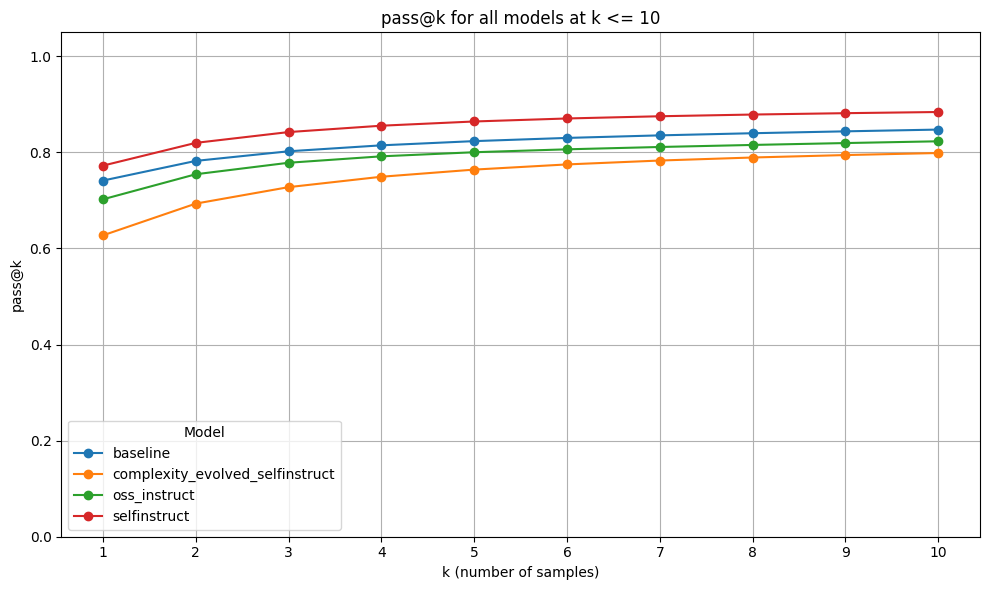

Saved: /content/drive/MyDrive/Speciale/4. Model Evaluation/results/passk_from_saved_runs/passk_curves.png


In [11]:
# =========================
# 12. Plot pass@k curves
# =========================
plt.figure(figsize=(10, 6))

for model_label, subdf in passk_summary.groupby('model_label'):
    plt.plot(subdf['k'], subdf['mean_pass_at_k'], marker='o', label=model_label)

plt.xticks(range(1, MAX_K + 1))
plt.ylim(0, 1.05)
plt.xlabel('k (number of samples)')
plt.ylabel('pass@k')
plt.title('pass@k for all models at k <= 10')
plt.legend(title='Model')
plt.tight_layout()
plt.savefig(PASSK_PLOT_PNG, dpi=200)
plt.show()

print('Saved:', PASSK_PLOT_PNG)


In [12]:
# =========================
# 13. Task-level paired pass@k comparison view
# =========================
baseline_view = baseline_stats[[
    'k', 'reference_model', 'comparison_model',
    'mean_diff_comparison_minus_reference',
    'ci95_low', 'ci95_high',
    'cohens_d_paired',
    'p_value_wilcoxon', 'p_value_wilcoxon_adj', 'significant_wilcoxon',
    'p_value_ttest', 'p_value_ttest_adj', 'significant_ttest',
]].copy()
print('Secondary task-level paired tests across HumanEval problems. For the 10-run small-sample comparison, use the run-level Welch table above as the main test.')
display(baseline_view)

sig_summary = (
    baseline_view.groupby('comparison_model', as_index=False)
    .agg(
        n_k_significant_wilcoxon=('significant_wilcoxon', 'sum'),
        n_k_significant_ttest=('significant_ttest', 'sum'),
        max_gain_vs_reference=('mean_diff_comparison_minus_reference', 'max'),
        min_gain_vs_reference=('mean_diff_comparison_minus_reference', 'min'),
    )
    .sort_values('n_k_significant_wilcoxon', ascending=False)
)
display(sig_summary)


,k,reference_model,comparison_model,mean_diff_comparison_minus_reference,ci95_low,ci95_high,cohens_d_paired,p_value_wilcoxon,p_value_wilcoxon_adj,significant_wilcoxon,p_value_ttest,p_value_ttest_adj,significant_ttest
0,1,baseline,complexity_evolved_selfinstruct,-0.114024,0.055104,0.172945,0.296185,0.000304,0.001518,True,0.000209,0.001047,True
1,2,baseline,complexity_evolved_selfinstruct,-0.088889,0.030162,0.147616,0.231657,0.003169,0.015847,True,0.003464,0.017319,True
2,3,baseline,complexity_evolved_selfinstruct,-0.074644,0.016578,0.132711,0.196746,0.006133,0.030664,True,0.012712,0.063559,False
3,4,baseline,complexity_evolved_selfinstruct,-0.065389,0.007728,0.123050,0.173564,0.012029,0.060146,False,0.027612,0.138058,False
4,5,baseline,complexity_evolved_selfinstruct,-0.059282,0.001741,0.116823,0.157681,0.016998,0.084990,False,0.045094,0.203731,False
5,6,baseline,complexity_evolved_selfinstruct,-0.055168,-0.002525,0.112862,0.146352,0.025164,0.125818,False,0.062690,0.250761,False
6,7,baseline,complexity_evolved_selfinstruct,-0.052388,-0.005712,0.110488,0.138004,0.039678,0.198391,False,0.079047,0.316189,False
7,8,baseline,complexity_evolved_selfinstruct,-0.050542,-0.008206,0.109290,0.131672,0.066570,0.266281,False,0.093665,0.374659,False
8,9,baseline,complexity_evolved_selfinstruct,-0.049390,-0.010224,0.109005,0.126801,0.097393,0.389571,False,0.106341,0.425362,False
9,10,baseline,complexity_evolved_selfinstruct,-0.048780,-0.011885,0.109446,0.123066,0.116664,0.466658,False,0.116962,0.467849,False


,comparison_model,n_k_significant_wilcoxon,n_k_significant_ttest,max_gain_vs_reference,min_gain_vs_reference
0,complexity_evolved_selfinstruct,3,2,-0.048780,-0.114024
1,oss_instruct,0,0,-0.022880,-0.039024
2,selfinstruct,0,0,0.040892,0.031098


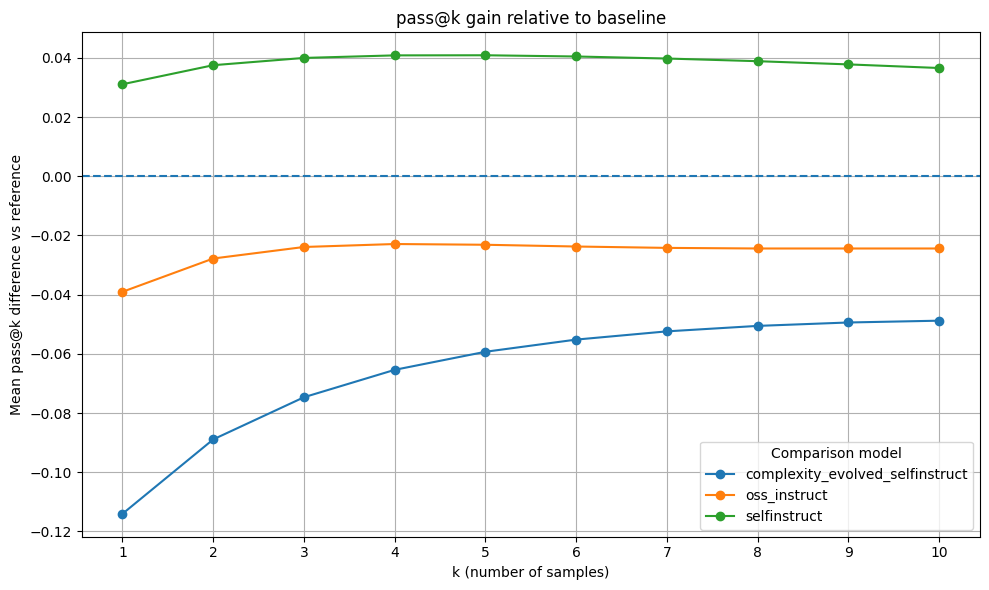

In [13]:
# =========================
# 14. Plot pass@k gain vs reference model
# =========================
plt.figure(figsize=(10, 6))
for comparison_model, subdf in baseline_stats.groupby('comparison_model'):
    plt.plot(
        subdf['k'],
        subdf['mean_diff_comparison_minus_reference'],
        marker='o',
        label=comparison_model,
    )

plt.axhline(0.0, linestyle='--')
plt.xticks(range(1, MAX_K + 1))
plt.xlabel('k (number of samples)')
plt.ylabel('Mean pass@k difference vs reference')
plt.title(f'pass@k gain relative to {detected_reference_model}')
plt.legend(title='Comparison model')
plt.tight_layout()
plt.show()


In [14]:

# 15. Optional wide-format table
# 12. Optional wide-format table
# =========================
passk_wide = passk_summary.pivot(index='k', columns='model_label', values='mean_pass_at_k')
display(passk_wide)

model_label,baseline,complexity_evolved_selfinstruct,oss_instruct,selfinstruct
k,,,,
1,0.741463,0.627439,0.702439,0.772561
2,0.782385,0.693496,0.754607,0.819919
3,0.802388,0.727744,0.778506,0.842378
4,0.814779,0.749390,0.791899,0.855633
5,0.823534,0.764252,0.800402,0.864426
6,0.830197,0.775029,0.806475,0.870674
7,0.835518,0.783130,0.811331,0.875305
8,0.839973,0.789431,0.815583,0.878862
9,0.843902,0.794512,0.819512,0.881707


In [15]:

# 16. Optional: show models ordered by pass@10
# 13. Optional: show models ordered by pass@10
# =========================
pass10 = (
    passk_summary[passk_summary['k'] == 10]
    .sort_values('mean_pass_at_k', ascending=False)
    .reset_index(drop=True)
)

display(pass10)

,model_label,k,mean_pass_at_k,sd_pass_at_k,n_tasks
0,selfinstruct,10,0.884146,0.321030,164
1,baseline,10,0.847561,0.360547,164
2,oss_instruct,10,0.823171,0.382693,164
3,complexity_evolved_selfinstruct,10,0.798780,0.402140,164
